
---

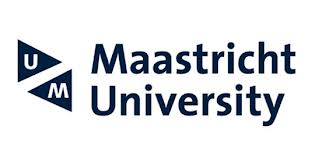

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


By Jan Scholtes


---

Version 2026-2027

---

Welcome to the tutorial on Deep Learning models for NLP. In this notebook you will learn how transformers and BERT models in particular caused a true revolution in NLP.

Ever since the introduction of the Transformer models, it has replaced RNN and LSTM for various NLP tasks. In fact, the success of transformers is so huge, that we will not even look at RNN and LSTM anymore in this tutorial. We did discuss them in the lectures, so you understand why Transformers are as good as they are for NLP tasks and how we got from grammar based NLP systems (via statistical) towards today's Transformers.

The tutorial below is based on code examples from "Natural Language Processing with Transformers" by Lewis Tunstall et al., "Transformers for Natural Language Processing" by Denis Rothman and "Getting Started with Google BERT" by S. Ravichandiran.

For this notebook we would need our GPU accelerator.

## Learning Goals

After completing this tutorial, you will be able to:

- **Understand** the self-attention mechanism and how it computes attention weights using Query, Key, and Value matrices.
- **Implement** scaled dot-product attention and multi-headed self-attention from scratch in PyTorch.
- **Explain** how feed-forward layers, layer normalization, and skip connections work in a Transformer encoder layer.
- **Describe** positional embeddings and why they are necessary for Transformers to capture word order.
- **Build** a complete Transformer encoder and attach a classification head for sequence classification.
- **Understand** the decoder architecture, including causal masking and different decoding strategies (greedy, beam search, top-k, nucleus).
- **Compare** the Transformer approach with generative grammars and statistical methods for NLP tasks.

#Self-Attention
Attention is the mechanism that allows neural networks to assign a different amount of weight or "attention" to each element in a sequence, in the case of natural lanague, such elements are the token embeddings.
Self-attention refers to the mechanism where the attention wieghts are calculated for all hidden states in the same set, e.g. all hidden states in the encoder.
LSTM's encode the attention of an entire sequence in the last hidden state before it is passed on to the decoder.

We can visualize how the attention weights are calculated using BertViz.

Let's calculate the self-attention for the sentence "time flies like an arrow". For the visualization to unfold, click the + at the left side of the visualization. You will now see the Query Q, Key K and qxk resulting in the softmax values. The intensity corresponds to to the magnitude. In layer 0 and head 8, you can observe, that "flies" has the strongest connection to "arrow".

In [ ]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()
from transformers import AutoTokenizer
from bertviz.transformers_neuron_view import BertModel
from bertviz.neuron_view import show

model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = BertModel.from_pretrained(model_ckpt)
text = "time flies like an arrow"
show(model, "bert", tokenizer, text, display_mode="light", layer=0, head=8)

Let's take a look at an individual transformer instead of the full BERT example from above and investigate the attention mechanism.

# Tokenize the text

In [ ]:
from transformers import AutoTokenizer
model_ckpt = "bert-base-uncased"
text = "time flies like an arrow"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)


In [ ]:
inputs = tokenizer(text, return_tensors="pt", add_special_tokens=False)
inputs.input_ids

The sentence is mapped to a sequence of unique tokens, with for each token a unique ID from tha tokenizer's vocabulary. The parameter "add_special_tokens=False" inplies that the special tokens CLS and SEP are not assigned an encoding.

Next, we need to create some "dense embeddings. "Dense" in this context means that each tokens gets a NON-ZERO value. In PyTorch we can use the code below for the lookups.

In [ ]:
from torch import nn
from transformers import AutoConfig

config = AutoConfig.from_pretrained(model_ckpt)
token_emb = nn.Embedding(config.vocab_size, config.hidden_size)
token_emb

Embedding(30522, 768} means that each input ID will be mapped to one of the 30.522 embedding vectors stored in nn.Embedding, each with size of 768. Note that in the standard transformers these embeddings are still context-free. So, homonums will have the same encoding. This will be taken care of in the subsequent attention layers, which will disambiguate the different meanings of the word "flies". Now we can generate the embeddings by feeding the input ID's from above.

In [ ]:
inputs_embeds = token_emb(inputs.input_ids)
inputs_embeds.size()

1 = batch_size, 5 = seq_len and 768 = hidden_dim. Next, let's create the query, key and value vectors and calculate the attention scoresusing the dot product as the similarity function.

In [ ]:
import torch
from math import sqrt

query = key = value = inputs_embeds
dim_k = key.size(-1)
scores = torch.bmm(query, key.transpose(1,2)) / sqrt(dim_k)
scores.size()

torch.Size[1,5,5] means that a 5 x 5 matrix of attention scores has been created in this batch. Later, we will see that the weight matrices W-Q, W-K and W-V can be used to set different values for Q, K and V (after training), but for now we will keep them equal.

Next, let's apply the softmax:

In [ ]:
import torch.nn.functional as F

weights = F.softmax(scores, dim=-1)
weights.sum(dim=-1)

And multiply the attention weights by the values:

In [ ]:
attn_outputs = torch.bmm(weights, value)
attn_outputs.shape

And we are done. A very simplified form of self-attention. All we did were 2 matrix multiplications and one softmax. One could say that "self-attention" is just a fancy form of averaging the word embeddings of a sequence of tokens.

We can wrap the above steps in a function that we can use later:

In [ ]:
def scaled_dot_product_attention(query, key, value):
    dim_k = query.size(-1)
    scores = torch.bmm(query, key.transpose(1, 2)) / sqrt(dim_k)
    weights = F.softmax(scores, dim=-1)
    return torch.bmm(weights, value)

Due to the equal weights for Q anf K, identical words in the context will get very high scores. By re-adjusting the weights for Q and K based on context, we can define different meanings the same (spelling - homonyms) words.  

#Multi-Headed Self Attention

Running multiple attention heads at the same time, allow us to look at all possible context at once. For instance, one head can deal with the subect-verb interaction, and another one finds nearby adjective. This is where the multiple layers come into place.

Let's first code a single attention head:

In [ ]:
class AttentionHead(nn.Module):
    def __init__(self, embed_dim, head_dim):
        super().__init__()
        self.q = nn.Linear(embed_dim, head_dim)
        self.k = nn.Linear(embed_dim, head_dim)
        self.v = nn.Linear(embed_dim, head_dim)

    def forward(self, hidden_state):
        attn_outputs = scaled_dot_product_attention(
            self.q(hidden_state), self.k(hidden_state), self.v(hidden_state))
        return attn_outputs

This initializes 3 independent linear layers. For example, BERT has 12 attention heads, so the dimension of each head = 768 / 12 = 64.

Next, concatenate the outputs of each single attention head which will result in a full multi-headed attention layer:


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        embed_dim = config.hidden_size
        num_heads = config.num_attention_heads
        head_dim = embed_dim // num_heads
        self.heads = nn.ModuleList(
            [AttentionHead(embed_dim, head_dim) for _ in range(num_heads)]
        )
        self.output_linear = nn.Linear(embed_dim, embed_dim)

    def forward(self, hidden_state):
        x = torch.cat([h(hidden_state) for h in self.heads], dim=-1)
        x = self.output_linear(x)
        return x

Now let's use the same settings as earlier from BERT and pass the Multi-headed attention to the model.

In [ ]:
multihead_attn = MultiHeadAttention(config)
attn_output = multihead_attn(inputs_embeds)
attn_output.size()

And let's visualize the results:

In [ ]:
from bertviz import head_view
from transformers import AutoModel

model = AutoModel.from_pretrained(model_ckpt, output_attentions=True)

sentence_a = "time flies like an arrow"
sentence_b = "fruit flies like a banana"

viz_inputs = tokenizer(sentence_a, sentence_b, return_tensors='pt')
attention = model(**viz_inputs).attentions
sentence_b_start = (viz_inputs.token_type_ids == 0).sum(dim=1)
tokens = tokenizer.convert_ids_to_tokens(viz_inputs.input_ids[0])

head_view(attention, tokens, sentence_b_start, heads=[8])

#The Feed-Forward Layer

The feed-forward sublayer (similar in the endcoder and the decoder) is a simple two layer fully-connected neural network. However, it does not process the entire sequence of token embeddings, it processes each embedding independently. This is also called: "position-wise feed-forward layer", a form of one dimensional convolution with a kernel size of one (if this is new to you: refer to this termonology  to how Convolution works in computer vision).

Here is the code for the feed forward mechanism:


In [ ]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_1 = nn.Linear(config.hidden_size, config.intermediate_size)
        self.linear_2 = nn.Linear(config.intermediate_size, config.hidden_size)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, x):
        x = self.linear_1(x)
        x = self.gelu(x)
        x = self.linear_2(x)
        x = self.dropout(x)
        return x

Let's forward the attention outputs through the feed-forward layers:

In [ ]:
feed_forward = FeedForward(config)
ff_outputs = feed_forward(attn_outputs)
ff_outputs.size()

#Adding Layer Normalization

Before we continue, we do need to apply normalization to make sure that each input in the batch have a mean of zero and the same unity variance.

In [ ]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layer_norm_1 = nn.LayerNorm(config.hidden_size)
        self.layer_norm_2 = nn.LayerNorm(config.hidden_size)
        self.attention = MultiHeadAttention(config)
        self.feed_forward = FeedForward(config)

    def forward(self, x):
        # Apply layer normalization and then copy input into query, key, value
        hidden_state = self.layer_norm_1(x)
        # Apply attention with a skip connection
        x = x + self.attention(hidden_state)
        # Apply feed-forward layer with a skip connection
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

And apply this to the input embeddings.

In [ ]:
encoder_layer = TransformerEncoderLayer(config)
inputs_embeds.shape, encoder_layer(inputs_embeds).size()

This whole process has now implemented all aspects of the encoder layer, except for the positional embeddings.

#Positional Embeddings

In languages, the order of the words and their position in a sentence really matters. The meaning of the entire sentence can change if the words are re-ordered. When implementing NLP solutions, recurrent neural networks have an inbuilt mechanism that deals with the order of sequences. The transformer model, however, does not use recurrence or convolution and treats each data point as independent of the other. Hence, positional information is added to the model explicitly to retain the information regarding the order of words in a sentence.

In transformers, positional embeddings is done in a really smart way by adding a phase to the embedding, based on a sinus/cosinus transformation as explained in the lecture.

There are many different ways to do this. Hereunder, we added the code for one of the methods.

(see https://machinelearningmastery.com/a-gentle-introduction-to-positional-encoding-in-transformer-models-part-1/ for more code examples)





In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def getPositionEncoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return P

P = getPositionEncoding(seq_len=4, d=4, n=100)
print(P)

To understand the positional encoding, let’s start by looking at the sine wave for different positions with n=10,000 and d=512.

In [ ]:
def plotSinusoid(k, d=512, n=10000):
    x = np.arange(0, 100, 1)
    denominator = np.power(n, 2*x/d)
    y = np.sin(k/denominator)
    plt.plot(x, y)
    plt.title('k = ' + str(k))

fig = plt.figure(figsize=(15, 4))
for i in range(4):
    plt.subplot(141 + i)
    plotSinusoid(i*4)

You can see that each position  corresponds to a different sinusoid, which encodes a single position into a vector.

Hence, the wavelengths of the sinusoids form a geometric progression and vary from 2 x pi to 2 x pi x n. The scheme for positional encoding has a number of advantages.

The sine and cosine functions have values in [-1, 1], which keeps the values of the positional encoding matrix in a normalized range.
As the sinusoid for each position is different, you have a unique way of encoding each position.
You have a way of measuring or quantifying the similarity between different positions, hence enabling you to encode the relative positions of words.

Let’s visualize the positional matrix on bigger values. Use Python’s matshow() method from the matplotlib library. Setting n=10,000 as done in the original paper, you get the following:

In [ ]:
P = getPositionEncoding(seq_len=100, d=512, n=10000)
cax = plt.matshow(P)
plt.gcf().colorbar(cax)

The positional encoding layer sums the positional vector with the word encoding and outputs this matrix for the subsequent layers. The entire process is shown below.

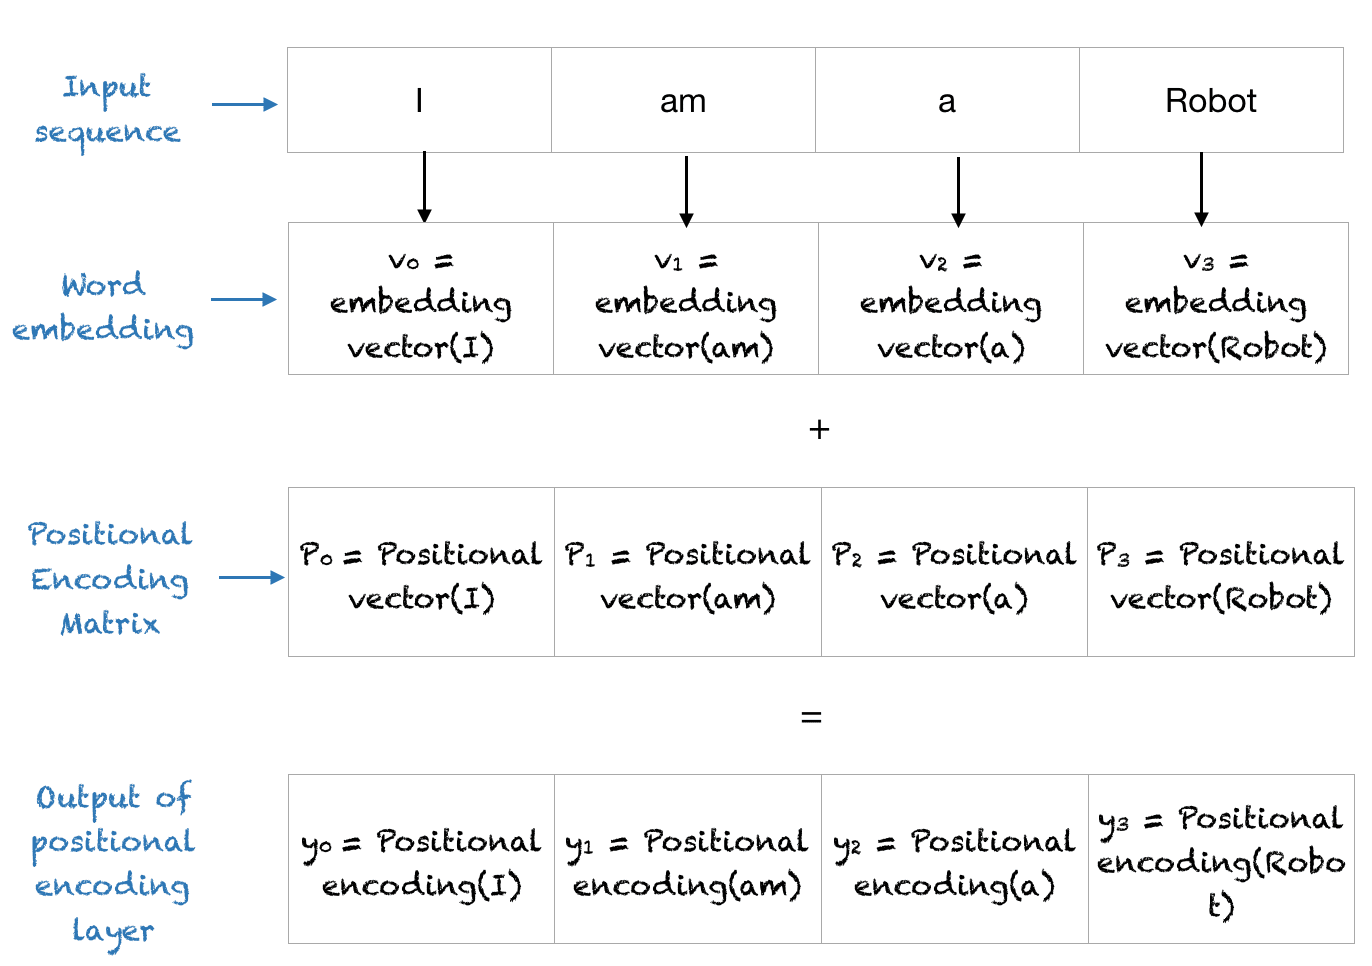

Let's create a class to add positional enciding to our embeddings:

In [ ]:
class Embeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embeddings = nn.Embedding(config.vocab_size,
                                             config.hidden_size)
        self.position_embeddings = nn.Embedding(config.max_position_embeddings,
                                                config.hidden_size)
        self.layer_norm = nn.LayerNorm(config.hidden_size, eps=1e-12)
        self.dropout = nn.Dropout()

    def forward(self, input_ids):
        # Create position IDs for input sequence
        seq_length = input_ids.size(1)
        position_ids = torch.arange(seq_length, dtype=torch.long).unsqueeze(0)
        # Create token and position embeddings
        token_embeddings = self.token_embeddings(input_ids)
        position_embeddings = self.position_embeddings(position_ids)
        # Combine token and position embeddings
        embeddings = token_embeddings + position_embeddings
        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings

Let's use this on on the embeddings.

In [ ]:
embedding_layer = Embeddings(config)
embedding_layer(inputs.input_ids).size()

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embeddings = Embeddings(config)
        self.layers = nn.ModuleList([TransformerEncoderLayer(config)
                                     for _ in range(config.num_hidden_layers)])

    def forward(self, x):
        x = self.embeddings(x)
        for layer in self.layers:
            x = layer(x)
        return x

In [ ]:
encoder = TransformerEncoder(config)
encoder(inputs.input_ids).size()

This model provides us with a hidden state for each token in the batch. We can use this for many different applications. One of them being a classifier.

#Adding a Classification Head

In [ ]:
class TransformerForSequenceClassification(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.encoder = TransformerEncoder(config)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, x):
        x = self.encoder(x)[:, 0, :] # select hidden state of [CLS] token
        x = self.dropout(x)
        x = self.classifier(x)
        return x

In [ ]:
config.num_labels = 3
encoder_classifier = TransformerForSequenceClassification(config)
encoder_classifier(inputs.input_ids).size()

#The Decoder

In [ ]:
seq_len = inputs.input_ids.size(-1)
mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0)
mask[0]

In [ ]:
scores.masked_fill(mask == 0, -float("inf"))

In [ ]:
def scaled_dot_product_attention(query, key, value, mask=None):
    dim_k = query.size(-1)
    scores = torch.bmm(query, key.transpose(1, 2)) / sqrt(dim_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return weights.bmm(value)

Here is a quick demonstration of decoding strategies. For an in-depth treatment of decoding (greedy, beam search, top-k, nucleus sampling) and prompt engineering, see **Tutorial 09** (Decoder Models / GPT).

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load a pre-trained language model and tokenizer
model_name = "gpt2"  # You can choose a different model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Set the padding token to the EOS token if it's not set
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

text = "The quick brown fox jumps over the lazy"
input_ids = tokenizer(text, return_tensors="pt").input_ids

# Greedy Search
print("Greedy Search:")
greedy_output = model.generate(input_ids, max_length=50, num_beams=1, early_stopping=True)
print(tokenizer.decode(greedy_output[0], skip_special_tokens=True))

# Beam Search
print("\nBeam Search (num_beams=5):")
beam_output = model.generate(input_ids, max_length=50, num_beams=5, early_stopping=True)
print(tokenizer.decode(beam_output[0], skip_special_tokens=True))

# Top-K Sampling
print("\nTop-K Sampling (top_k=50):")
# Set do_sample=True for sampling
topk_output = model.generate(input_ids, max_length=50, do_sample=True, top_k=50)
print(tokenizer.decode(topk_output[0], skip_special_tokens=True))

# Top-P Sampling (Nucleus Sampling) - included as it's often used with top-k
print("\nTop-P Sampling (top_p=0.9):")
# Set do_sample=True for sampling
topp_output = model.generate(input_ids, max_length=50, do_sample=True, top_p=0.9)
print(tokenizer.decode(topp_output[0], skip_special_tokens=True))

# More Transformer Details

The recent ["Attention is All You Need"] (https://arxiv.org/abs/1706.03762) paper from NIPS 2017 introduced Transformers. Here: https://nlp.seas.harvard.edu/2018/04/03/attention.html you can find an excellent tutorial that takes you through the paper, step by step, using a python tutorial on Colab: https://drive.google.com/file/d/1xQXSv6mtAOLXxEMi8RvaW8TW-7bvYBDF/view. We highly recommend that you go through the paper by using this tuturial yourself to fully understand the inner-workings of transformers.

After this tutorial, continue with the second part of this tutorial (BERT) in Tutorial 08.

## Conceptual Reflection Questions

*These questions help you prepare for exam-style conceptual questions. Practice explaining these in your own words, without code.*

1. **CNN vs RNN/LSTM vs Transformer**: Why don't CNNs work well for NLP? Why are RNNs/LSTMs better? How do Transformers improve on LSTMs?

2. **Multi-headed self-attention**: What are the two main advantages of splitting attention into multiple heads instead of using one large attention head?

3. **Feed-Forward Network**: What role does the FFN play in each Transformer layer? Why is self-attention alone insufficient?

4. **Positional encoding**: Why do Transformers need positional encoding? What would happen to a machine translation model if you removed the encoder and fed word embeddings directly to the decoder?

5. **Decoding strategies**: Given a translation model with these probabilities for translating "the house" to Dutch:
   - P("de"|start) = 0.6, P("het"|start) = 0.4
   - P("huis"|"de") = 0.51, P("woning"|"de") = 0.49
   - P("huis"|"het") = 0.9, P("woning"|"het") = 0.1
   
   What does greedy search produce? What does beam search (beam=2) produce? Why do they differ?

## Take Away

### Key Concepts

| Concept | Description |
|---|---|
| **Self-Attention** | Mechanism that allows each token to attend to all other tokens in a sequence. Computes attention weights using Query, Key, Value matrices and scaled dot-product. |
| **Scaled Dot-Product Attention** | $\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$ — scaling prevents vanishing gradients in softmax. |
| **Multi-Headed Self-Attention (MHSA)** | Runs multiple attention heads in parallel, each capturing different relationships (e.g., syntactic, semantic). Outputs are concatenated and linearly projected. |
| **Feed-Forward Network** | Two-layer MLP with GELU activation, applied independently to each token position. Adds non-linearity and increases model capacity. |
| **Layer Normalization** | Normalizes inputs to have zero mean and unit variance. Combined with skip connections (Pre-LN) for stable training. |
| **Positional Embeddings** | Since attention is permutation-invariant, positional encodings (sinusoidal or learned) are added to token embeddings to capture word order. |
| **Encoder** | Stack of N Transformer layers (MHSA + FFN + LayerNorm + skip connections) that produces contextualized representations. |
| **Classification Head** | Linear layer on top of the [CLS] token's hidden state for sequence classification tasks. |
| **Decoder** | Uses causal (lower-triangular) masking to prevent attending to future tokens during autoregressive generation. |
| **Decoding Strategies** | Greedy (fastest, deterministic), Beam Search (explores multiple paths), Top-k/Nucleus (sampling for creative generation). |

### Architecture Summary

1. **Input** → Token Embeddings + Positional Embeddings
2. **Encoder Layer** (×N): LayerNorm → MHSA → Skip Connection → LayerNorm → FFN → Skip Connection
3. **Output**: Contextualized hidden states for each token
4. **Classification**: Use [CLS] token → Dropout → Linear classifier

# Exercises

## Exercise A1: Multi-Headed Self-Attention (10 points)

Based on the BERTViz visualization of multi-headed self-attention above:

**a)** (5 points) What can be observed from the multi-headed self-attention visualization? Describe the attention patterns you see across different heads and layers. How do different heads seem to specialize?

**b)** (5 points) How does multi-headed self-attention help in disambiguating the different meanings of the word "flies" in the sentences "time flies like an arrow" and "fruit flies like a banana"? Refer to specific attention patterns you observe.

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Encoder for POS Tagging (10 points)

**a)** (5 points) Explain how a Transformer encoder with a classification head can be used as a POS (Part-of-Speech) tagger. What modifications would be needed compared to the `TransformerForSequenceClassification` class shown in the tutorial? Be specific about the architectural differences.

**b)** (5 points) Why is the Transformer encoder particularly well-suited for POS tagging compared to simpler approaches (e.g., rule-based or unigram taggers)? What role does self-attention play in resolving POS ambiguity?

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Decoding Strategies (10 points)

The scaffold below loads GPT-2 and runs **greedy search** and **beam search** for you.

**a)** (5 points - code) Add **top-k sampling** (k=50) and **nucleus/top-p sampling** (p=0.95) to the `decoding_results` dictionary. Use temperature=0.7 for both.

**b)** (5 points - explanation) Compare all four outputs. Which strategy produces the most natural text? Which is most repetitive? When would you use each in practice?

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# --- Scaffold: Model loading and basic decoding (provided) ---
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

text = "The quick brown fox jumps over the lazy"
input_ids = tokenizer(text, return_tensors="pt").input_ids

# Greedy Search (provided)
greedy_output = model.generate(input_ids, max_length=50, num_beams=1)
greedy_text = tokenizer.decode(greedy_output[0], skip_special_tokens=True)
print("GREEDY:", greedy_text)

# Beam Search (provided)
beam_output = model.generate(input_ids, max_length=50, num_beams=5, early_stopping=True)
beam_text = tokenizer.decode(beam_output[0], skip_special_tokens=True)
print("BEAM:  ", beam_text)

decoding_results = {"greedy": greedy_text, "beam": beam_text}

# --- YOUR CODE: Add top-k and top-p sampling ---
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A3 (5 points)
assert isinstance(decoding_results, dict), "decoding_results must be a dictionary"
assert "greedy" in decoding_results, "Must have greedy decoding result"
assert "beam" in decoding_results, "Must have beam search result"
assert "topk" in decoding_results, "Must have top-k sampling result"
assert "topp" in decoding_results, "Must have top-p sampling result"
assert all(len(v) > len(text) for v in decoding_results.values()), "All outputs should be longer than the prompt"
print("All A3 code tests passed!")

**b) Write your comparison below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Comparing Transformers with Generative Grammars and Statistical Methods (10 points)

**a)** (5 points) Complete the comparison table below, filling in each cell with a brief explanation (1-2 sentences per cell):

| Aspect | Generative Grammars (CFGs) | Statistical (HMMs/CRFs) | Transformers |
|---|---|---|---|
| How they handle sequences | ? | ? | ? |
| Long-range dependencies | ? | ? | ? |
| Handling ambiguity | ? | ? | ? |
| Learning from data | ? | ? | ? |

**b)** (5 points) Give **two NLP tasks** where Transformers clearly outperform grammars and statistical methods, with a brief explanation why (2-3 sentences each).

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## References

- Vaswani, A. et al. "Attention Is All You Need." NeurIPS 2017. https://arxiv.org/abs/1706.03762
- Tunstall, L. et al. "Natural Language Processing with Transformers." O'Reilly, 2022.
- Rothman, D. "Transformers for Natural Language Processing." Packt, 2021.
- Ravichandiran, S. "Getting Started with Google BERT." Packt, 2021.
- BERTViz: Vig, J. "A Multiscale Visualization of Attention in the Transformer Model." ACL 2019. https://github.com/jessevig/bertviz
- Harvard NLP: "The Annotated Transformer." https://nlp.seas.harvard.edu/2018/04/03/attention.html